# Training

In [1]:
#Imports
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import glob
from skimage.feature import hog
import time
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.cross_validation import train_test_split
from moviepy.editor import VideoFileClip
from IPython.display import HTML
from scipy.ndimage.measurements import label as apply_label
import pickle
from VehicleDetectionFunctions import *
from VehicleDetector import VehicleDetector

%matplotlib inline

/home/peter/anaconda3/envs/carnd-term1/lib/python3.5/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


## Feature Evaluation

In [2]:
vehicle_images = []
nonvehicle_images = []
for img_filename in glob.glob('./training/vehicles/**/*.png', recursive=True):
    image = mpimg.imread(img_filename)
    vehicle_images.append(image)
    
for img_filename in glob.glob('./training/non-vehicles/**/*.png', recursive=True):
    image = mpimg.imread(img_filename)
    nonvehicle_images.append(image)
    
    

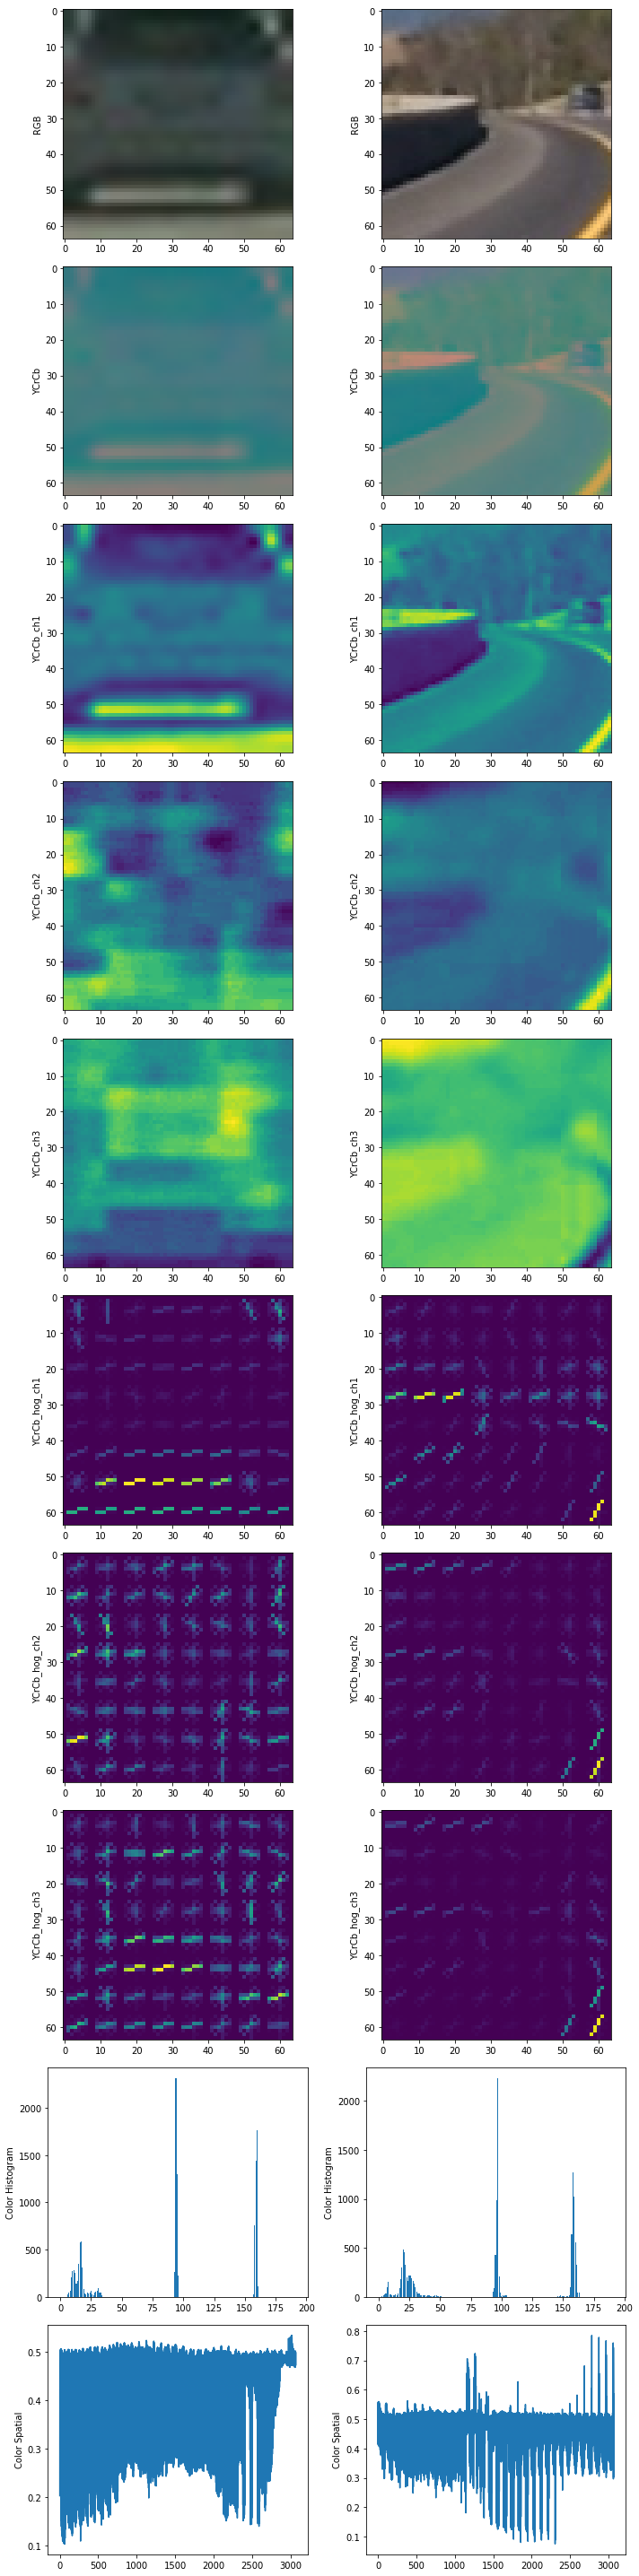

In [3]:
asdf = np.random.randint(0,6000)
vehicle_image = vehicle_images[asdf]
nonvehicle_image = nonvehicle_images[1433]

fig, ax = plt.subplots(10, 2, figsize=(10, 40))
orient=9
pix_per_cell=8
cell_per_block=2
nbins=64
size=(32,32)
cspace = 'YCrCb'
for i, img in enumerate([vehicle_image, nonvehicle_image]):
    ax[0][i].imshow(img)
    ax[0][i].set_ylabel('RGB')
    
    cvtimg = cvt_color(img, cspace)
    ax[1][i].imshow(cvtimg)
    ax[1][i].set_ylabel(cspace)
    ax[2][i].imshow(cvtimg[:,:,0])
    ax[2][i].set_ylabel(cspace+'_ch'+str(1))
    ax[3][i].imshow(cvtimg[:,:,1])
    ax[3][i].set_ylabel(cspace+'_ch'+str(2))
    ax[4][i].imshow(cvtimg[:,:,2])
    ax[4][i].set_ylabel(cspace+'_ch'+str(3))

    feathog, hog1 = get_hog_features(cvtimg[:,:,0],orient,pix_per_cell,
                                     cell_per_block,vis=True)
    ax[5][i].imshow(hog1)
    ax[5][i].set_ylabel(cspace+'_hog_ch'+str(1))
    
    feathog, hog2 = get_hog_features(cvtimg[:,:,1],orient,pix_per_cell,
                                     cell_per_block,vis=True)
    ax[6][i].imshow(hog2)
    ax[6][i].set_ylabel(cspace+'_hog_ch'+str(2))
    
    feathog, hog3 = get_hog_features(cvtimg[:,:,2],orient,pix_per_cell,
                                     cell_per_block,vis=True)
    ax[7][i].imshow(hog3)
    ax[7][i].set_ylabel(cspace+'_hog_ch'+str(3))
    
    hist_bins = color_hist(cvtimg, nbins, (0,1.0))
    ax[8][i].bar(range(len(hist_bins)),hist_bins)
    ax[8][i].set_ylabel('Color Histogram')
    
    spatial = bin_spatial(img, color_space=cspace, size=size)
    ax[9][i].plot(spatial)
    ax[9][i].set_ylabel('Color Spatial')

plt.tight_layout()
plt.savefig('./figs/vehicle_features.png')

## Import Images and extract Features

In [4]:
vehicle_features = []
nonvehicle_features = []
#Import images

cspace = 'YCrCb'

for image in vehicle_images:
    features = gen_features(image, color_space=cspace, n_hist=64, hog_chan='ALL')
    vehicle_features.append(features)

for image in nonvehicle_images:
    features = gen_features(image, color_space=cspace, n_hist=64, hog_chan='ALL')
    nonvehicle_features.append(features)




## SVM Classifier

In [5]:
# Create an array stack of feature vectors
X = np.vstack((vehicle_features, nonvehicle_features)).astype(np.float64)    

# Fit a per-column scaler
X_scaler = StandardScaler().fit(X)
# Apply the scaler to X
scaled_X = X_scaler.transform(X)

# Define the labels vector
y = np.hstack((np.ones(len(vehicle_features)), np.zeros(len(nonvehicle_features))))
# Split up data into randomized training and test sets
rand_state = np.random.randint(0, 100)
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, y, test_size=0.2, random_state=rand_state)

print('Feature vector length:', len(X_train[0]))
# Use a linear SVC 
svc = LinearSVC()
# Check the training time for the SVC
t=time.time()
svc.fit(X_train, y_train)
t2 = time.time()
print(round(t2-t, 2), 'Seconds to train SVC...')
# Check the score of the SVC
print('Test Accuracy of SVC = ', round(svc.score(X_test, y_test), 4))
# Check the prediction time for a single sample
t=time.time()
n_predict = 100
print('My SVC predicts: ', svc.predict(X_test[0:n_predict]))
print('For these',n_predict, 'labels: ', y_test[0:n_predict])
t2 = time.time()
print(round(t2-t, 5), 'Seconds to predict', n_predict,'labels with SVC')

Feature vector length: 8556
6.96 Seconds to train SVC...
Test Accuracy of SVC =  0.9899
My SVC predicts:  [ 1.  0.  0.  1.  0.  0.  1.  0.  1.  0.  1.  1.  0.  0.  0.  0.  1.  0.
  0.  0.  1.  0.  1.  0.  1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.
  1.  1.  1.  0.  0.  0.  1.  1.  0.  0.  0.  1.  1.  0.  1.  1.  0.  0.
  0.  0.  1.  1.  1.  1.  0.  0.  0.  1.  0.  1.  1.  0.  0.  0.  0.  1.
  1.  1.  1.  1.  1.  1.  0.  1.  1.  0.  0.  1.  0.  0.  1.  1.  0.  1.
  1.  0.  0.  0.  1.  0.  0.  1.  0.  1.]
For these 100 labels:  [ 1.  1.  0.  1.  0.  0.  1.  0.  1.  0.  1.  1.  0.  0.  0.  0.  1.  0.
  0.  0.  1.  0.  1.  0.  1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.
  1.  1.  1.  0.  0.  0.  1.  1.  0.  0.  0.  1.  1.  0.  1.  1.  0.  0.
  0.  0.  1.  1.  1.  1.  0.  0.  0.  1.  0.  1.  1.  0.  0.  0.  0.  1.
  1.  1.  1.  1.  1.  1.  0.  1.  1.  0.  0.  1.  0.  0.  1.  1.  1.  1.
  1.  0.  0.  0.  1.  0.  0.  1.  0.  1.]
0.00391 Seconds to predict 100 labels with SVC


In [6]:
#Save Pickle
pickle.dump( (svc, X_scaler), open('svc.p', 'wb') )
